In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"C:\Users\Lala\Downloads\archive\WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [30]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Flag
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,80,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,80,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,80,1,17,3,3,5,2,0,3,0
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,80,1,9,5,3,7,7,1,7,0
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,80,1,6,0,3,6,2,0,3,0
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,80,0,17,3,2,9,6,0,8,0


In [27]:
df['Attrition_Flag'] = (df['Attrition'] == 'Yes').astype(int)

numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()['Attrition_Flag'].drop('Attrition_Flag')

top10 = corr.reindex(corr.abs().sort_values(ascending=False).index).head(10)

In [28]:
top10

TotalWorkingYears      -0.171063
JobLevel               -0.169105
YearsInCurrentRole     -0.160545
MonthlyIncome          -0.159840
Age                    -0.159205
YearsWithCurrManager   -0.156199
StockOptionLevel       -0.137145
YearsAtCompany         -0.134392
JobInvolvement         -0.130016
JobSatisfaction        -0.103481
Name: Attrition_Flag, dtype: float64

### Bütün korrelyasiyalar mənfi işarəlidir — yəni bu göstəricilər artdıqca, attrition ehtimalı azalır. Ən güclü əlaqə TotalWorkingYears (ümumi iş təcrübəsi) ilədir . təcrübə az olduqca, işçinin çıxma ehtimalı yüksəkdir.bütün dəyərlər 0.2-dən aşağıdır - əlaqələr zəif-orta səviyyədədir.

# Horizontal Bar

AttributeError: Line2D.set() got an unexpected keyword argument 'edgecolor'

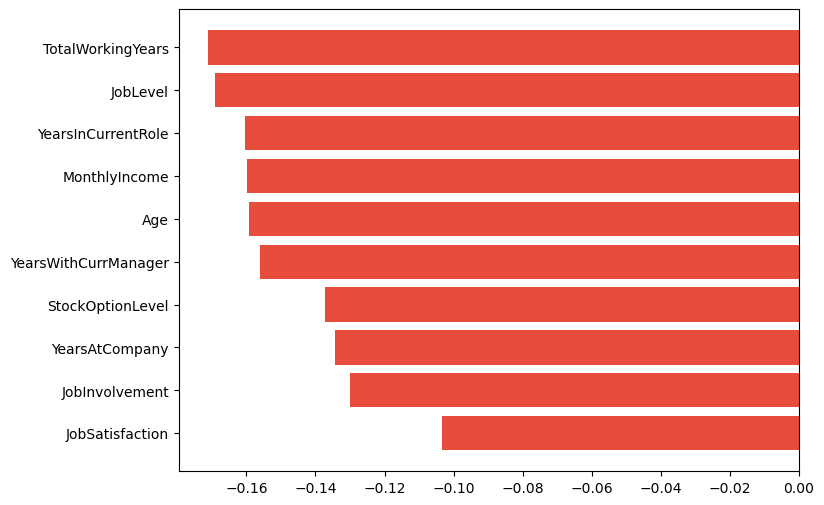

In [33]:
colors = ['#e74c3c' if i < 0 else '#2ecc71' for i in top10.values]

plt.figure(figsize=(8, 6))
plt.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1])
plt.axvline(0, color='black',edgecolor='black')
plt.xlabel('Correlation with Attrition')
plt.title('Top 10 Features Correlated with Attrition')
plt.show()